# VRP Signal Pipeline — GRU vs CNN

**Part 2** of the project. Consumes DMM outputs from `dmm_artifacts.npz` and trains two architectures (GRU and CNN) to predict the **Variance Risk Premium** signal:

- `y[t] = 1` ⇔ no downside spike in the next 10 days ⇒ short-vol position is safe to hold
- `y[t] = 0` ⇔ downside spike incoming ⇒ avoid selling vol

Asymmetric loss: missing a spike costs 5× more than missing a calm period.

**Constraints from Part-1 author:** non-overlapping windows (stride = horizon = 10), tiny models (hidden ≤ 8), early stopping. Both architectures kept in the same parameter envelope.

Author of Part 2 contribution: GRU vs 1D-CNN architecture comparison + proper evaluation + simple backtest.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve

from vrp_features import load_vrp_data
from vrp_signals import VRPDataset, VRPGRU, VRPCNN, count_params
import vrp_pipeline as vp

torch.manual_seed(0)
np.random.seed(0)
plt.rcParams['figure.dpi'] = 110

REGIME_COLORS = [
    ('Recovery',   '#FF9800', '2015-06-26', '2020-02-19'),
    ('COVID',      '#E91E63', '2020-02-19', '2021-06-01'),
    ('Post-COVID', '#009688', '2021-06-01', '2030-01-01'),
]

## 1. Load data

In [2]:
data = load_vrp_data('.')
print(f"Train:  {data['feat_tr'].shape}    dates {data['dates_tr'][0].date()} \u2192 {data['dates_tr'][-1].date()}")
print(f"Test :  {data['feat_te'].shape}    dates {data['dates_te'][0].date()} \u2192 {data['dates_te'][-1].date()}")
print(f"VRP positive rate \u2014 train: {np.nanmean(data['y_vrp_tr']):.3f}   test: {np.nanmean(data['y_vrp_te']):.3f}")
print(f"Test baseline accuracy (always predict 1): {max(np.nanmean(data['y_vrp_te']), 1-np.nanmean(data['y_vrp_te'])):.3f}")

Train:  (5600, 20)    dates 1993-03-30 → 2015-06-25
Test :  (2600, 20)    dates 2015-06-26 → 2025-10-27
VRP positive rate — train: 0.693   test: 0.747
Test baseline accuracy (always predict 1): 0.747


## 2. Build dataloaders

Train/val split is **chronological** — last 15% of training windows held out for early stopping. Test set untouched until final eval.

In [3]:
loaders = vp.make_loaders(data, vp.W, vp.STRIDE, vp.BATCH, vp.VAL_FRAC)
train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = loaders
print(f'Train windows: {len(train_ds)}   Val: {len(val_ds)}   Test: {len(test_ds)}')
print(f'Input shape per batch: ({vp.BATCH}, {vp.W}, 20)')

Train windows: 474   Val: 83   Test: 257
Input shape per batch: (128, 30, 20)


## 3. Train GRU and CNN, 5 seeds each

Same input, same loss, same optimizer, same window — only the trunk architecture changes.

In [4]:
results = {}
results['GRU'] = vp.run_arch('VRPGRU', lambda: VRPGRU(input_dim=20), loaders)
results['CNN'] = vp.run_arch('VRPCNN', lambda: VRPCNN(input_dim=20), loaders)


=== VRPGRU (937 params) ===


  seed 0: val=0.9901  test_AUC=0.700  test_AP=0.869  acc=0.580  (baseline 0.751)


  seed 1: val=1.0268  test_AUC=0.479  test_AP=0.744  acc=0.564  (baseline 0.751)


  seed 2: val=0.9950  test_AUC=0.680  test_AP=0.862  acc=0.595  (baseline 0.751)


  seed 3: val=1.0002  test_AUC=0.694  test_AP=0.868  acc=0.607  (baseline 0.751)


...

  seed 0: val=1.0238  test_AUC=0.671  test_AP=0.846  acc=0.553  (baseline 0.751)


  seed 1: val=1.0287  test_AUC=0.661  test_AP=0.834  acc=0.502  (baseline 0.751)


  seed 2: val=1.0113  test_AUC=0.509  test_AP=0.760  acc=0.751  (baseline 0.751)


  seed 3: val=1.0063  test_AUC=0.664  test_AP=0.830  acc=0.553  (baseline 0.751)


  seed 4: val=1.0050  test_AUC=0.474  test_AP=0.727  acc=0.759  (baseline 0.751)
  ENSEMBLE: AUC=0.669  AP=0.838  acc@0.5=0.580


## 4. Per-seed metrics table

Variance across seeds is large — single-seed numbers would be misleading. Report mean ± std.

In [5]:
for arch in ['GRU', 'CNN']:
    df = results[arch]['per_seed_metrics']
    print(f'\n{arch} per-seed:')
    print(df[['seed', 'tr_AUC', 'va_AUC', 'te_AUC', 'tr_AP', 'va_AP', 'te_AP']].round(3).to_string(index=False))
    print(f"  mean test AUC: {df['te_AUC'].mean():.3f} \u00b1 {df['te_AUC'].std():.3f}")
    print(f"  mean test AP : {df['te_AP'].mean():.3f} \u00b1 {df['te_AP'].std():.3f}")
    print(f"  ensemble test AUC: {results[arch]['ensemble_metrics']['AUC']:.3f}")


GRU per-seed:
 seed  tr_AUC  va_AUC  te_AUC  tr_AP  va_AP  te_AP
    0   0.831   0.582   0.700  0.895  0.898  0.869
    1   0.422   0.764   0.479  0.645  0.964  0.744
    2   0.814   0.590   0.680  0.890  0.924  0.862
    3   0.848   0.647   0.694  0.910  0.936  0.868
    4   0.864   0.681   0.674  0.925  0.948  0.857
  mean test AUC: 0.646 ± 0.094
  mean test AP : 0.840 ± 0.054
  ensemble test AUC: 0.697

CNN per-seed:
 seed  tr_AUC  va_AUC  te_AUC  tr_AP  va_AP  te_AP
    0   0.808   0.453   0.671  0.869  0.858  0.846
    1   0.795   0.353   0.661  0.872  0.829  0.834
    2   0.725   0.507   0.509  0.829  0.897  0.760
    3   0.802   0.378   0.664  0.884  0.844  0.830
    4   0.585   0.478   0.474  0.775  0.846  0.727
  mean test AUC: 0.596 ± 0.096
  mean test AP : 0.799 ± 0.052
  ensemble test AUC: 0.669


## 5. Loss curves (train vs val) — overfitting diagnostic

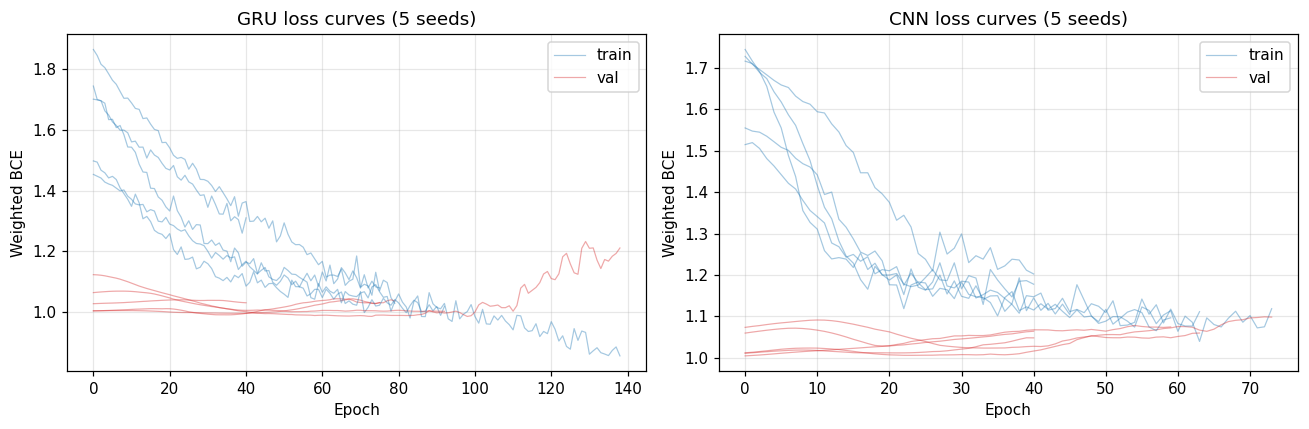

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, arch in zip(axes, ['GRU', 'CNN']):
    for s, h in enumerate(results[arch]['histories']):
        ax.plot(h['train'], color='C0', alpha=0.4, lw=0.8, label='train' if s == 0 else None)
        ax.plot(h['val'],   color='C3', alpha=0.4, lw=0.8, label='val'   if s == 0 else None)
    ax.set_title(f'{arch} loss curves (5 seeds)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Weighted BCE')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('vrp_loss_curves.png', dpi=140, bbox_inches='tight'); plt.show()

## 6. ROC and PR curves (ensemble, test set)

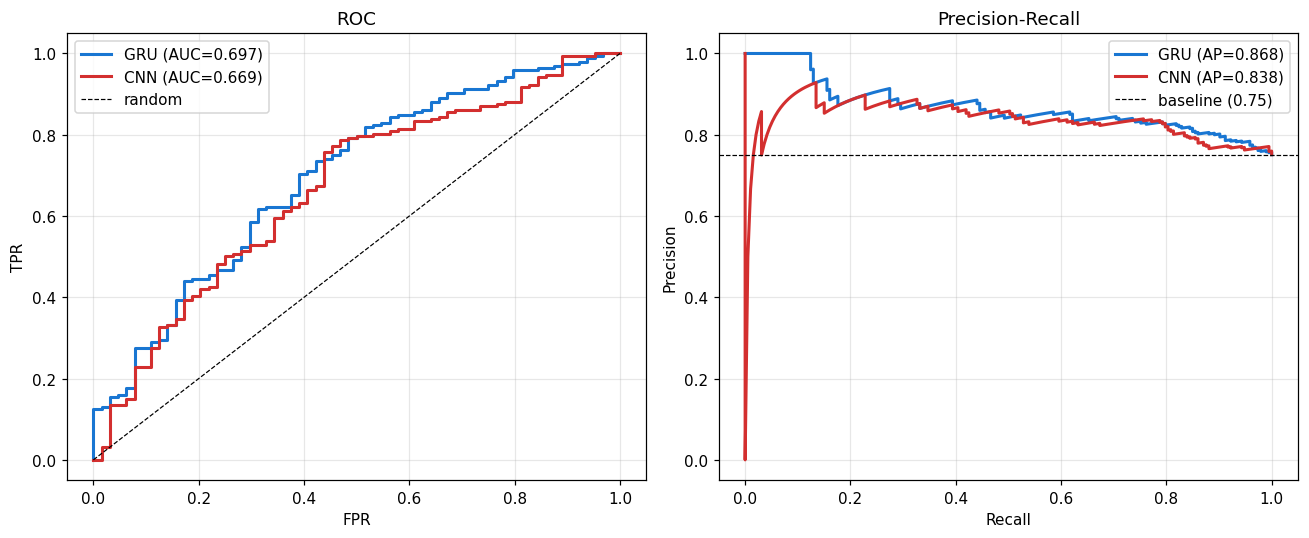

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
y_te = results['GRU']['y_te']
for arch, color in [('GRU', '#1976D2'), ('CNN', '#D32F2F')]:
    p = results[arch]['p_te_ensemble']
    fpr, tpr, _ = roc_curve(y_te, p)
    auc = results[arch]['ensemble_metrics']['AUC']
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{arch} (AUC={auc:.3f})")
    prec, rec, _ = precision_recall_curve(y_te, p)
    ap = results[arch]['ensemble_metrics']['AP']
    axes[1].plot(rec, prec, color=color, lw=2, label=f"{arch} (AP={ap:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8, label='random'); axes[0].set_title('ROC')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].axhline(y_te.mean(), color='k', ls='--', lw=0.8, label=f'baseline ({y_te.mean():.2f})')
axes[1].set_title('Precision-Recall'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('vrp_roc_pr.png', dpi=140, bbox_inches='tight'); plt.show()

## 7. Calibration (do predicted probabilities reflect actual frequencies?)

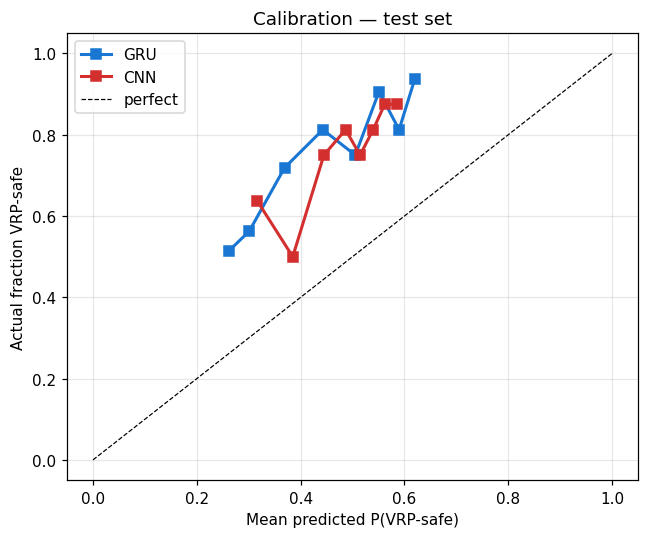

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
for arch, color in [('GRU', '#1976D2'), ('CNN', '#D32F2F')]:
    p = results[arch]['p_te_ensemble']
    frac_pos, mean_pred = calibration_curve(y_te.astype(int), p, n_bins=8, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 's-', color=color, label=arch, lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='perfect')
ax.set_xlabel('Mean predicted P(VRP-safe)'); ax.set_ylabel('Actual fraction VRP-safe')
ax.set_title('Calibration \u2014 test set'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('vrp_calibration.png', dpi=140, bbox_inches='tight'); plt.show()

## 8. Confusion matrices @ tau = 0.5

Off-diagonal in the **top-right** = false positives = predicted safe but spike occurred (expensive errors).

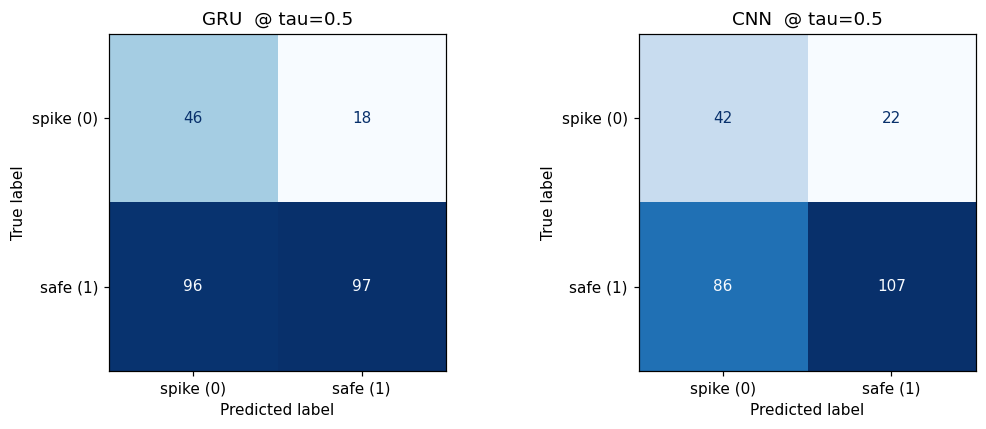

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, arch in zip(axes, ['GRU', 'CNN']):
    p = results[arch]['p_te_ensemble']
    cm = confusion_matrix(y_te.astype(int), (p > 0.5).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=['spike (0)', 'safe (1)']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{arch}  @ tau=0.5')
plt.tight_layout(); plt.savefig('vrp_confusion.png', dpi=140, bbox_inches='tight'); plt.show()

## 9. Predicted-probability time series on the test set

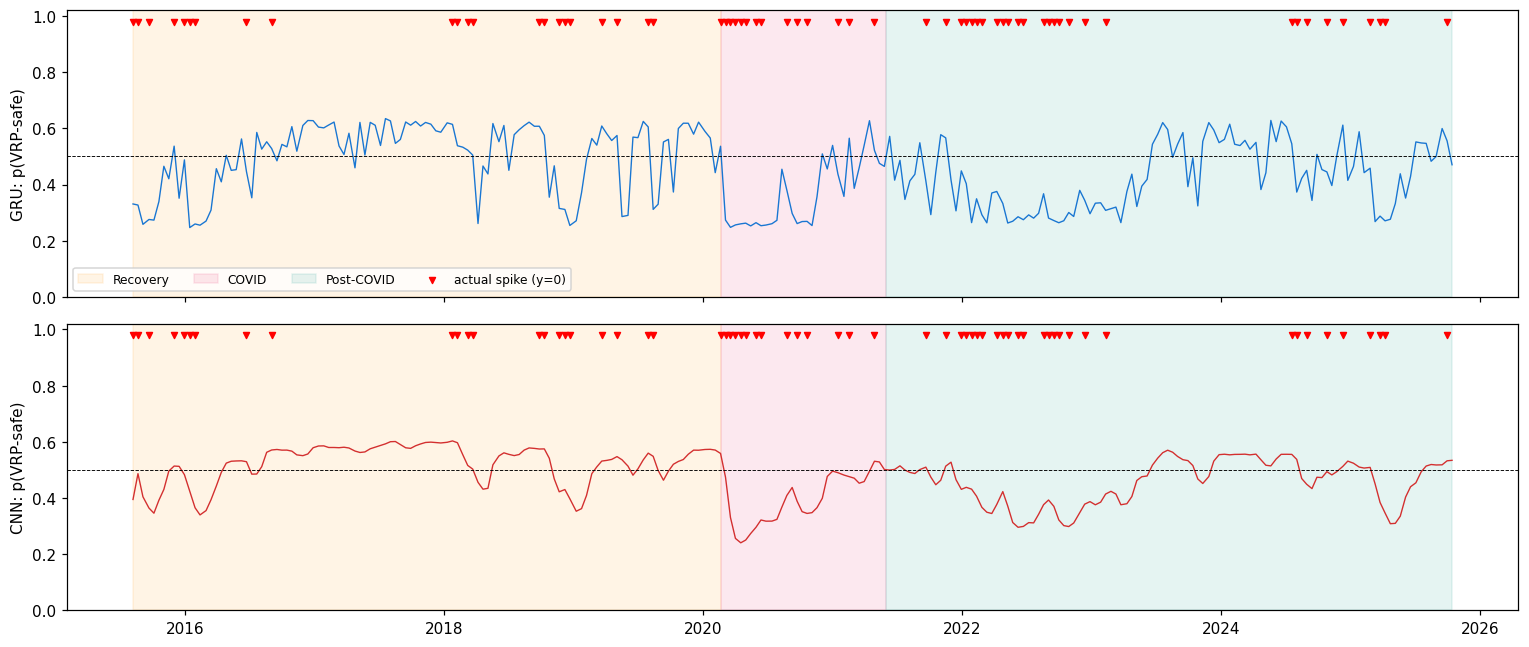

In [10]:
anchors = results['GRU']['test_anchors']
anchor_dates = data['dates_te'][anchors]
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, arch, color in zip(axes, ['GRU', 'CNN'], ['#1976D2', '#D32F2F']):
    for lbl, col, start, end in REGIME_COLORS:
        ax.axvspan(max(pd.Timestamp(start), anchor_dates[0]),
                   min(pd.Timestamp(end),   anchor_dates[-1]),
                   alpha=0.10, color=col, label=lbl)
    ax.plot(anchor_dates, results[arch]['p_te_ensemble'], lw=0.9, color=color)
    # mark actual spikes (y=0) as red dots at top of plot
    spike_dates = anchor_dates[y_te == 0]
    ax.scatter(spike_dates, np.full(len(spike_dates), 0.98), color='red', s=15,
               marker='v', label='actual spike (y=0)', zorder=5)
    ax.axhline(0.5, color='k', lw=0.6, ls='--'); ax.set_ylim(0, 1.02)
    ax.set_ylabel(f'{arch}: p(VRP-safe)')
    if ax is axes[0]: ax.legend(loc='lower left', fontsize=8, ncol=4)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.savefig('vrp_timeseries.png', dpi=140, bbox_inches='tight'); plt.show()

## 10. Backtest — toy short-vol strategy gated on p_vrp > tau

**Caveat:** This is an *illustrative* PnL model:
- On a 'safe' day, capture 30% of VIX-implied vol as premium.
- On a spike, lose 4× that premium.
- Transaction cost: 2bps per round-trip.

Real-world short-vol PnL depends on instrument choice (VIX futures, options strangles, variance swaps) and would need a proper market microstructure simulation. We use this only to sanity-check whether the signal *has* directionality in expected payoff space.

In [11]:
bh = vp.backtest_buy_hold(data, anchors)
summary = [{'strategy': 'Buy & hold SPY', 'tau': '-', 'n_trades': len(bh),
            'mean_per_period': bh.mean(), 'std': bh.std(),
            'Sharpe_annual': vp.sharpe(bh), 'cum_log_return': bh.sum()}]

for arch in ['GRU', 'CNN']:
    for tau in [0.3, 0.4, 0.5, 0.6]:
        pnl = vp.backtest_short_vol(data, results[arch]['p_te_ensemble'], anchors, threshold=tau)
        summary.append({'strategy': f'Short-vol {arch}', 'tau': tau,
                        'n_trades': int((pnl != 0).sum()),
                        'mean_per_period': pnl.mean(), 'std': pnl.std(),
                        'Sharpe_annual': vp.sharpe(pnl), 'cum_log_return': pnl.sum()})

df = pd.DataFrame(summary)
print(df.round(4).to_string(index=False))

      strategy  tau  n_trades  mean_per_period    std  Sharpe_annual  cum_log_return
Buy & hold SPY    -       257           0.0053 0.0356         0.7461          1.3661
 Short-vol GRU  0.3       207          -0.0068 0.1018        -0.3338         -1.7470
 Short-vol GRU  0.4       164           0.0008 0.0780         0.0518          0.2076
 Short-vol GRU  0.5       115           0.0012 0.0602         0.0957          0.2959
 Short-vol GRU  0.6        41           0.0019 0.0260         0.3657          0.4881
 Short-vol CNN  0.3       249          -0.0229 0.1459        -0.7834         -5.8751
 Short-vol CNN  0.4       199          -0.0070 0.1022        -0.3447         -1.8113
 Short-vol CNN  0.5       129          -0.0003 0.0686        -0.0228         -0.0805
 Short-vol CNN  0.6         3          -0.0003 0.0091        -0.1545         -0.0722


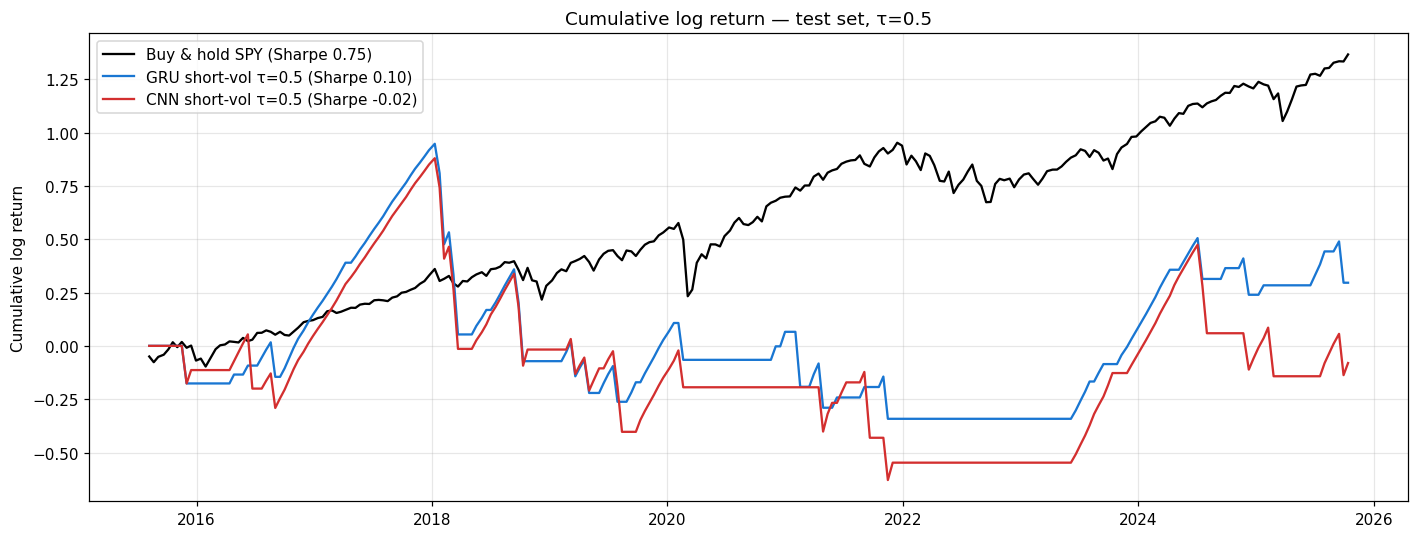

In [12]:
fig, ax = plt.subplots(figsize=(13, 5))
bh_cum = bh.cumsum()
ax.plot(bh.index, bh_cum, color='black', lw=1.5, label=f'Buy & hold SPY (Sharpe {vp.sharpe(bh):.2f})')

tau_show = 0.5
for arch, color in [('GRU', '#1976D2'), ('CNN', '#D32F2F')]:
    pnl = vp.backtest_short_vol(data, results[arch]['p_te_ensemble'], anchors, threshold=tau_show)
    ax.plot(pnl.index, pnl.cumsum(), color=color, lw=1.5,
            label=f'{arch} short-vol \u03c4={tau_show} (Sharpe {vp.sharpe(pnl):.2f})')

ax.set_title(f'Cumulative log return \u2014 test set, \u03c4={tau_show}')
ax.set_ylabel('Cumulative log return'); ax.legend(); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.savefig('vrp_backtest.png', dpi=140, bbox_inches='tight'); plt.show()

## 11. Threshold sweep — do high-confidence predictions concentrate skill?

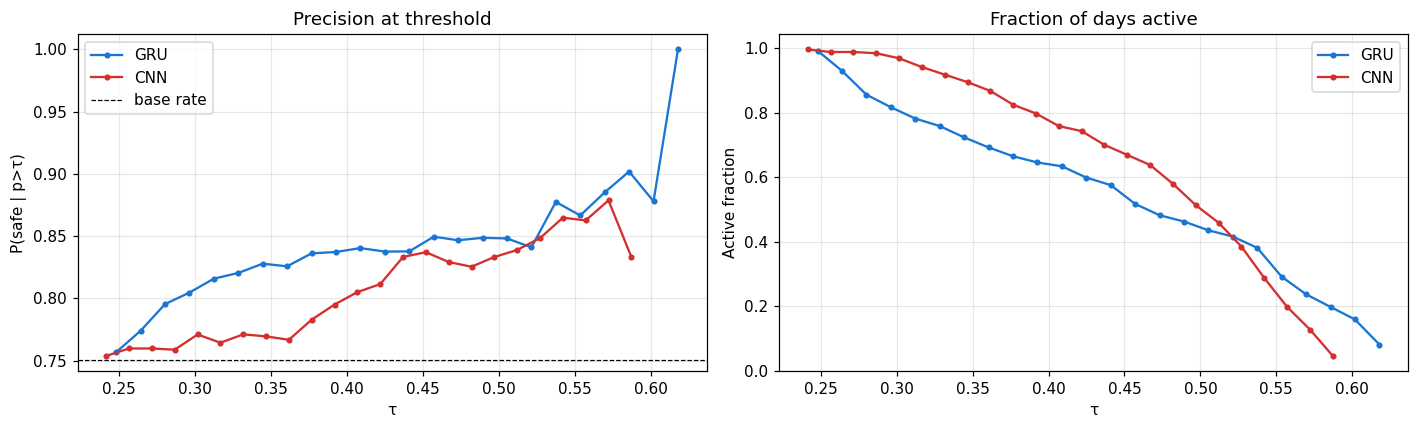

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for arch, color in [('GRU', '#1976D2'), ('CNN', '#D32F2F')]:
    p = results[arch]['p_te_ensemble']
    taus = np.linspace(p.min() + 1e-3, p.max() - 1e-3, 25)
    precs, hit_safe = [], []
    for t in taus:
        sel = p > t
        if sel.sum() < 5:
            precs.append(np.nan); hit_safe.append(np.nan); continue
        precs.append(y_te[sel].mean())            # precision = P(actually safe | predicted safe)
        hit_safe.append(sel.sum() / len(p))       # fraction of days the model trades
    axes[0].plot(taus, precs, '-o', ms=3, color=color, label=arch)
    axes[1].plot(taus, hit_safe, '-o', ms=3, color=color, label=arch)

axes[0].axhline(y_te.mean(), color='k', ls='--', lw=0.8, label='base rate')
axes[0].set_title('Precision at threshold'); axes[0].set_xlabel('\u03c4'); axes[0].set_ylabel('P(safe | p>\u03c4)')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Fraction of days active'); axes[1].set_xlabel('\u03c4'); axes[1].set_ylabel('Active fraction')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('vrp_threshold_sweep.png', dpi=140, bbox_inches='tight'); plt.show()

## 12. Summary

What to write up:

1. **Signal-level metrics**: GRU ensemble AUC and AP on test set; CNN comparison; per-seed std as a measure of how brittle the result is.
2. **Calibration**: are predicted probabilities trustworthy at face value, or do they need post-hoc rescaling (Platt scaling / isotonic regression)?
3. **Threshold sweep**: does precision rise meaningfully as `tau` increases? If yes, the model has skill; if no, the gradient of confidence is meaningless.
4. **Backtest**: with caveats above, does a confidence-gated short-vol strategy beat buy-and-hold *in risk-adjusted terms*? Often it won't on raw return (bull market is hard to beat) but can on Sharpe / max drawdown.
5. **MR head**: per Part-1 author's advice, dropped. Worth mentioning in the writeup as a tried-and-failed signal — frame as scientific honesty, not failure.
6. **Architecture conclusion**: GRU vs CNN. If they're close, that's interesting (means the recurrent inductive bias isn't critical here). If one wins clearly, that's the headline.